# 14 · Métricas para classe rara — PR-AUC vs ROC-AUC (ADR-0015)

Detecção de anomalias é **fortemente desbalanceada** (poucas anomalias entre muitas janelas
normais). A **ROC-AUC engana** nesse regime: o excesso de verdadeiros-negativos infla a
pontuação. A métrica honesta é a **PR-AUC** (área sob a curva Precision–Recall), que foca na
classe positiva. Aqui medimos as duas sob a injeção sintética (ground-truth conhecido) e
mostramos o exagero da ROC.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

from src.config import CONFIG, set_seeds
from src import data, preprocessing as pp, train as T, detect as D
from src.evaluate import inject_price_shocks, labels_to_window_labels, score_curves, expected_cost
from src.viz import save_fig

set_seeds()
TICKERS = CONFIG["tickers"]
W = CONFIG["preprocessing"]["window_size"]

def scores_labels(t, n_inj):
    df = data.load_ticker(t)
    r = pp.log_returns(df); r_tr, r_te = pp.temporal_split(r)
    sc = pp.fit_scaler(r_tr); sigma = float(np.std(pp.apply_scaler(sc, r_tr)))
    perturbed, labels, _ = inject_price_shocks(pp.apply_scaler(sc, r_te), n_injections=n_inj, sigma=sigma)
    err = D.reconstruction_error(T.load_model(t), pp.make_windows(perturbed))  # escore continuo
    return err, labels_to_window_labels(labels)

## 1. A armadilha do nosso próprio sintético: janelas sobrepostas inflam a classe

Cada injeção contamina ~`window_size` janelas (rótulo positivo se **qualquer** passo da janela foi
injetado). Com as 50 injeções default, a "anomalia" deixa de ser rara e vira **maioria** — o
cenário 99/1 da motivação **não se materializa** ao nível de janela. Variamos `n_injections` para
percorrer do raro ao abundante (PETR4):

In [2]:
rows = []
for n_inj in [2, 5, 10, 25, 50]:
    err, wl = scores_labels("PETR4.SA", n_inj)
    sc = score_curves(err, wl)
    rows.append({"n_injections": n_inj, "prevalencia": round(sc["prevalence"], 3),
                 "PR_AUC": round(sc["pr_auc"], 3), "ROC_AUC": round(sc["roc_auc"], 3),
                 "PR_lift": round(sc["pr_lift"], 2)})
sweep = pd.DataFrame(rows).set_index("n_injections")
print("PETR4 — quanto mais raro (menos injeções), mais a ROC engana:")
sweep

PETR4 — quanto mais raro (menos injeções), mais a ROC engana:


,prevalencia,PR_AUC,ROC_AUC,PR_lift
n_injections,,,,
2,0.049,0.151,0.840,3.06
5,0.105,0.314,0.847,3.00
10,0.188,0.537,0.921,2.86
25,0.447,0.707,0.878,1.58
50,0.715,0.865,0.885,1.21


## 2. Onde a ROC engana

No regime **raro** (poucas injeções), a **ROC-AUC permanece alta** (muitos verdadeiros-negativos
dominam o FPR) enquanto a **PR-AUC despenca** rumo à prevalência — exatamente o ponto da ideia.
No regime abundante (50 injeções) as duas convergem porque a classe deixou de ser rara.

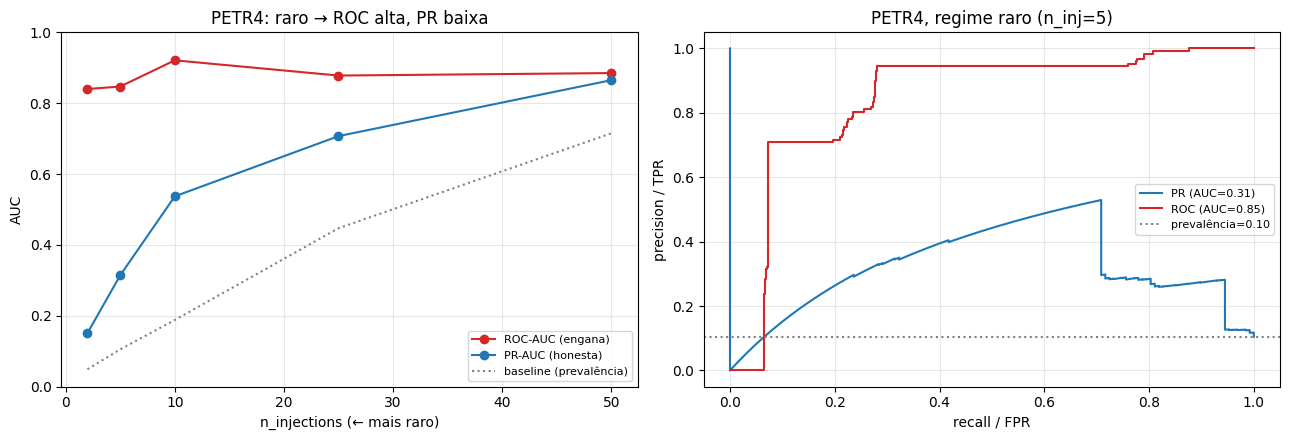

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(sweep.index, sweep["ROC_AUC"], "o-", color="tab:red", label="ROC-AUC (engana)")
a1.plot(sweep.index, sweep["PR_AUC"], "o-", color="tab:blue", label="PR-AUC (honesta)")
a1.plot(sweep.index, sweep["prevalencia"], ":", color="gray", label="baseline (prevalência)")
a1.set_xlabel("n_injections (← mais raro)"); a1.set_ylabel("AUC"); a1.set_ylim(0, 1)
a1.set_title("PETR4: raro → ROC alta, PR baixa"); a1.legend(fontsize=8); a1.grid(alpha=0.3)

# curvas no cenário raro (n_inj=5)
err, wl = scores_labels("PETR4.SA", 5)
prec, rec, _ = precision_recall_curve(wl, err); fpr, tpr, _ = roc_curve(wl, err)
sc = score_curves(err, wl)
a2.plot(rec, prec, color="tab:blue", label=f"PR (AUC={sc['pr_auc']:.2f})")
a2.plot(fpr, tpr, color="tab:red", label=f"ROC (AUC={sc['roc_auc']:.2f})")
a2.axhline(sc["prevalence"], color="gray", ls=":", label=f"prevalência={sc['prevalence']:.2f}")
a2.set_title("PETR4, regime raro (n_inj=5)"); a2.set_xlabel("recall / FPR"); a2.set_ylabel("precision / TPR")
a2.legend(fontsize=8); a2.grid(alpha=0.3)
fig.tight_layout(); save_fig(fig, "m12_pr_vs_roc"); plt.show()

## 3. Custo assimétrico: Falsos Positivos vs Falsos Negativos

Deixar passar um choque (FN) raramente custa o mesmo que um alarme falso (FP). Variando o peso
relativo `cost_fn`, vê-se como o custo total se desloca — base para escolher o limiar conforme o
apetite a risco (sem inventar uma estratégia de portfólio, ADR-0016).

In [4]:
rows = []
for t in TICKERS:
    err, wl = scores_labels(t, 50)
    err_tr = D.reconstruction_error(T.load_model(t), pp.preprocess_ticker(data.load_ticker(t))["X_train"])
    flags = D.flag_anomalies(err, D.static_threshold(err_tr))
    for c_fn in [1, 5, 10]:
        ec = expected_cost(flags, wl, cost_fp=1.0, cost_fn=c_fn)
        rows.append({"ticker": t, "cost_fn": c_fn, "FP": ec["fp"], "FN": ec["fn"], "custo": ec["cost"]})
print("Custo total (cost_fp=1) sob diferentes pesos de FN, limiar p95:")
pd.DataFrame(rows).set_index(["ticker", "cost_fn"])

Custo total (cost_fp=1) sob diferentes pesos de FN, limiar p95:


FP   FN   custo
ticker   cost_fn                 
PETR4.SA 1        35  753   788.0
         5        35  753  3800.0
         10       35  753  7565.0
VALE3.SA 1        33  402   435.0
         5        33  402  2043.0
         10       33  402  4053.0
AMER3.SA 1        88  383   471.0
         5        88  383  2003.0
         10       88  383  3918.0
ITUB4.SA 1        33  718   751.0
         5        33  718  3623.0
         10       33  718  7213.0

## Conclusões

- **A ideia está certa — e expôs um problema do nosso próprio sintético.** No regime **raro**
  (poucas injeções), a ROC-AUC permanece alta enquanto a PR-AUC cai à prevalência: a ROC **engana**,
  como a ideia alertou. **PR-AUC é a métrica honesta** para classe rara.
- **Mas a injeção default (50) não é rara:** janelas sobrepostas fazem cada choque rotular ~30
  janelas → a "anomalia" vira maioria (~70%), e aí ROC≈PR. Ou seja, o cenário 99/1 da motivação
  **não se materializa** ao nível de janela com a config atual. Correção sugerida: reduzir
  `n_injections` (ou contar eventos contíguos como um) para avaliar no regime realmente raro.
- **PR-AUC entra como métrica padrão** (`score_curves`), reportada ao lado de F1; ROC-AUC só como
  contraste didático. Na ausência de rótulos no teste **real** (não supervisionado), a PR-AUC é
  computável apenas sobre o sintético.
- **Custo FP×FN** mostra a escolha de limiar como decisão de risco. A tradução plena para dinheiro
  (portfólio) fica como trabalho futuro — ver ADR-0016.